In [1]:
from sklearn.preprocessing import StandardScaler
from utils.evaluation import *
from utils.load_data import load_processed_data
from models.dnn import DNN
from models.linear_regression import LinearRegressionSklearn 
import torch
from torch.utils.data import DataLoader, Dataset

## Load data

In [2]:
data_path = '../data/processed'
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(data_path)

X_train shape: torch.Size([2132, 33]), y_train shape: torch.Size([2132, 1])
X_val shape: torch.Size([457, 33]), y_val shape: torch.Size([457, 1])
X_test shape: torch.Size([458, 33]), y_test shape: torch.Size([458, 1])


In [3]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
batch_size = 128

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training and Evaluation

#### Hyperparameters

In [5]:
epochs = 500
learning_rate = 0.01
dropout = 0.3
batch_norm = True
l2_lambda = 1e-4
grad_clip = False

In [6]:
def pipeline(
        model, 
        epochs=50, 
        verbose=True, 
        early_stopping=False, 
        patience=10, 
        grad_clip=True
):
    train_losses, val_losses = model.fit(
        train_loader, 
        val_loader, 
        epochs=epochs, 
        verbose=verbose, 
        early_stopping=early_stopping, 
        patience=patience, 
        grad_clip=grad_clip
    )
    test_model(model, X_test, y_test)
    plot_loss(train_losses, val_losses, log=True)

### Linear Regression

In [7]:
lr = LinearRegressionSklearn()
lr.fit(X_train, y_train)
test_model(lr, X_test, y_test)


=========== Model Evaluation ===========
Mean Absolute Error (MAE): 9.8655
Mean Squared Error (MSE): 187.7547
R^2 Score: 0.7460


### DNN-16

In [8]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
)
dnn_16.model

Sequential(
  (0): Linear(in_features=33, out_features=16, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 376.7688, Val Loss: 394.0416
Epoch [100/500], Train Loss: 270.4584, Val Loss: 315.5546
Epoch [150/500], Train Loss: 201.5114, Val Loss: 250.2628
Epoch [200/500], Train Loss: 155.1504, Val Loss: 210.2430
Epoch [250/500], Train Loss: 128.5258, Val Loss: 188.2772
Epoch [300/500], Train Loss: 112.8933, Val Loss: 168.4011
Epoch [350/500], Train Loss: 102.4323, Val Loss: 169.6169
Epoch [400/500], Train Loss: 98.0069, Val Loss: 161.6612
Epoch [450/500], Train Loss: 89.9191, Val Loss: 162.1725
Epoch [500/500], Train Loss: 88.4214, Val Loss: 159.3788

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 8.3993
Mean Squared Error (MSE): 131.2905
R^2 Score: 0.8224


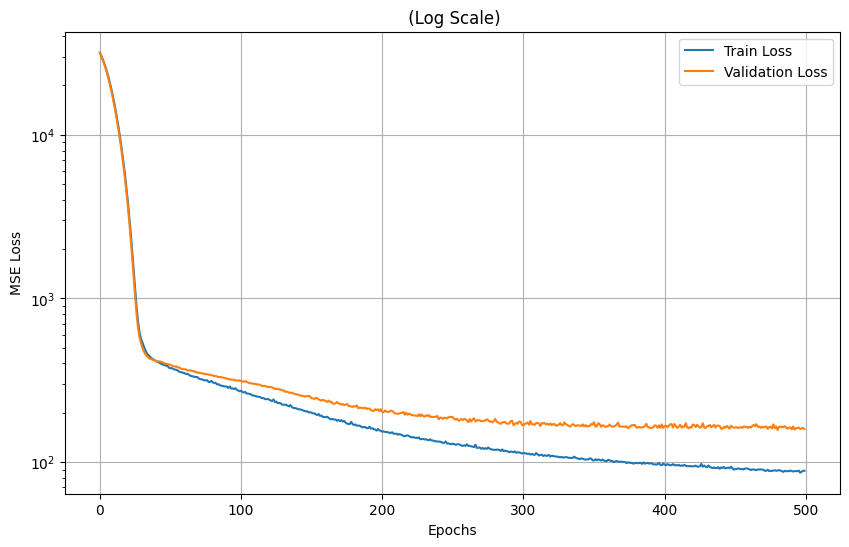

In [9]:
pipeline(dnn_16, epochs=epochs)

## DNN-30-8

In [10]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=33, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=8, bias=True)
  (3): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Sigmoid()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 1721.5948, Val Loss: 615.2335
Epoch [100/500], Train Loss: 1564.7412, Val Loss: 488.7533
Epoch [150/500], Train Loss: 1394.4441, Val Loss: 422.8756
Epoch [200/500], Train Loss: 1396.8279, Val Loss: 356.8492
Epoch [250/500], Train Loss: 1357.9907, Val Loss: 372.8766
Epoch [300/500], Train Loss: 1242.9935, Val Loss: 334.5675
Epoch [350/500], Train Loss: 1275.1631, Val Loss: 294.6742
Epoch [400/500], Train Loss: 1215.0323, Val Loss: 305.3650
Epoch [450/500], Train Loss: 1220.0106, Val Loss: 298.9039
Epoch [500/500], Train Loss: 1191.8630, Val Loss: 268.2630

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 10.7888
Mean Squared Error (MSE): 204.6269
R^2 Score: 0.7231


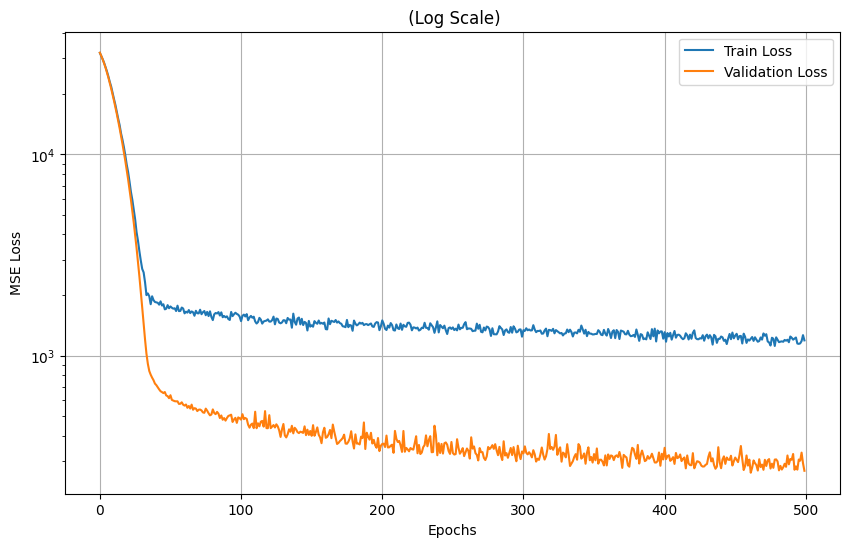

In [11]:
pipeline(dnn_30_8, epochs=epochs)

## DNN-30-16-8

In [12]:
dnn_30_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_16_8.model

Sequential(
  (0): Linear(in_features=33, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Sigmoid()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): Sigmoid()
  (9): Dropout(p=0.3, inplace=False)
  (10): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 1845.5129, Val Loss: 642.5434
Epoch [100/500], Train Loss: 1502.1438, Val Loss: 460.7311
Epoch [150/500], Train Loss: 1517.3020, Val Loss: 416.7924
Epoch [200/500], Train Loss: 1492.1448, Val Loss: 362.0303
Epoch [250/500], Train Loss: 1342.5074, Val Loss: 349.1056
Epoch [300/500], Train Loss: 1321.7242, Val Loss: 330.9402
Epoch [350/500], Train Loss: 1274.6077, Val Loss: 300.0539
Epoch [400/500], Train Loss: 1227.3654, Val Loss: 297.4194
Epoch [450/500], Train Loss: 1242.8213, Val Loss: 291.4501
Epoch [500/500], Train Loss: 1172.9051, Val Loss: 261.6220

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 10.9317
Mean Squared Error (MSE): 218.5580
R^2 Score: 0.7043


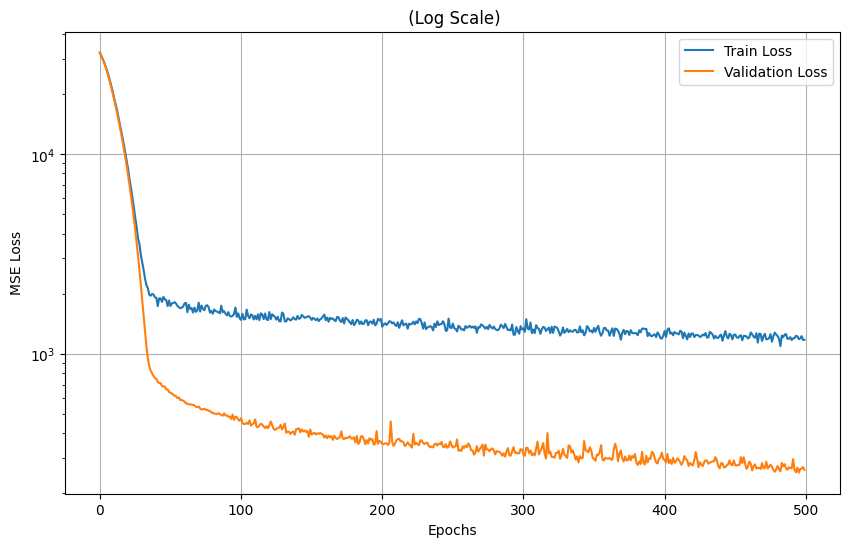

In [13]:
pipeline(dnn_30_16_8, epochs=epochs)

## DNN-30-16-8-4

In [14]:
dnn_30_16_8_4 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8, 4],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
dnn_30_16_8_4.model

Sequential(
  (0): Linear(in_features=33, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Sigmoid()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): Sigmoid()
  (9): Dropout(p=0.3, inplace=False)
  (10): Linear(in_features=8, out_features=4, bias=True)
  (11): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): Sigmoid()
  (13): Dropout(p=0.3, inplace=False)
  (14): Linear(in_features=4, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 2461.2858, Val Loss: 897.5445
Epoch [100/500], Train Loss: 2008.5199, Val Loss: 630.7667
Epoch [150/500], Train Loss: 1776.2506, Val Loss: 534.2120
Epoch [200/500], Train Loss: 1677.8505, Val Loss: 485.0060
Epoch [250/500], Train Loss: 1619.2933, Val Loss: 464.7036
Epoch [300/500], Train Loss: 1607.4888, Val Loss: 452.0609
Epoch [350/500], Train Loss: 1500.5036, Val Loss: 402.6901
Epoch [400/500], Train Loss: 1436.6130, Val Loss: 398.2735
Epoch [450/500], Train Loss: 1460.9869, Val Loss: 374.3576
Epoch [500/500], Train Loss: 1322.6365, Val Loss: 323.5454

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 12.5259
Mean Squared Error (MSE): 305.4636
R^2 Score: 0.5867


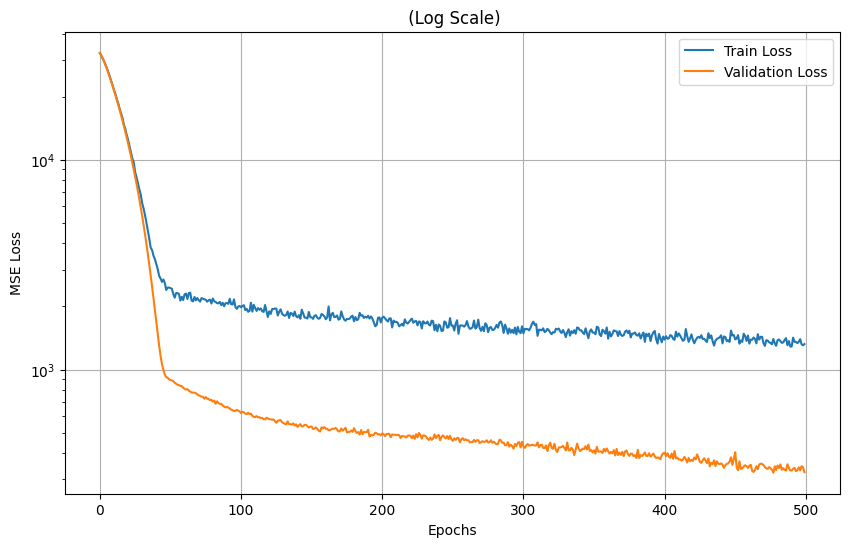

In [15]:
pipeline(dnn_30_16_8_4, epochs=epochs)

## Custom DNN

In [16]:
custom_dnn = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[128, 64, 32, 16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda
)
custom_dnn.model

Sequential(
  (0): Linear(in_features=33, out_features=128, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): Sigmoid()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): Sigmoid()
  (9): Dropout(p=0.3, inplace=False)
  (10): Linear(in_features=32, out_features=16, bias=True)
  (11): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): Sigmoid()
  (13): Dropout(p=0.3, inplace=False)
  (14): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 1168.9248, Val Loss: 462.1847
Epoch [100/500], Train Loss: 1076.4875, Val Loss: 387.8289
Epoch [150/500], Train Loss: 1047.5638, Val Loss: 336.3864
Epoch [200/500], Train Loss: 1016.1769, Val Loss: 313.6722
Epoch [250/500], Train Loss: 981.7091, Val Loss: 317.4410
Epoch [300/500], Train Loss: 992.1807, Val Loss: 271.5337
Epoch [350/500], Train Loss: 966.8220, Val Loss: 259.0131
Epoch [400/500], Train Loss: 904.0892, Val Loss: 243.0529
Epoch [450/500], Train Loss: 881.2613, Val Loss: 235.4589
Epoch [500/500], Train Loss: 822.8570, Val Loss: 228.6127

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 10.6039
Mean Squared Error (MSE): 203.4378
R^2 Score: 0.7247


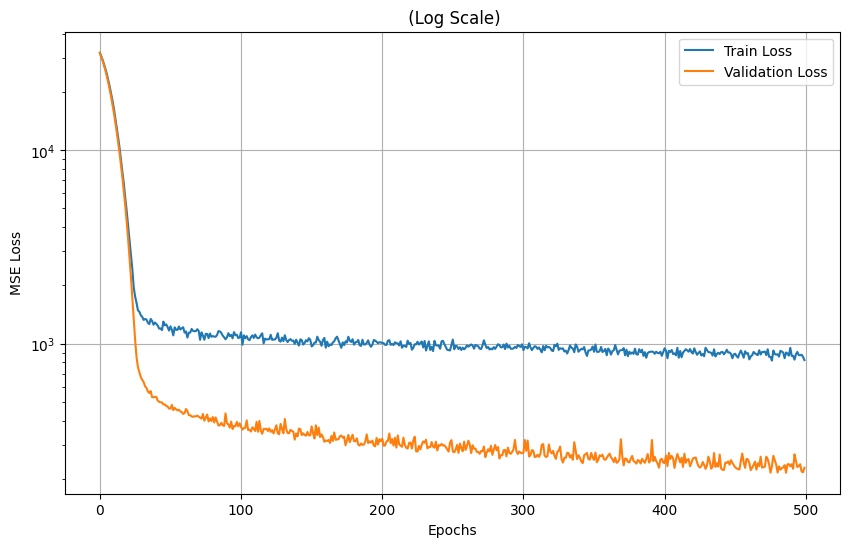

In [17]:
pipeline(custom_dnn, epochs=epochs)